# Pattern feature

In [2]:
import datetime
import os
import shutil
import sys
import time

import numpy as np
import path
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys

from pathlib import Path
from collections import Counter
from utils import *

parent_dir = Path.cwd().parent.resolve()

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from data import data
from logger import get_logger
from prepare import accuracy, fetch_data, initialise

In [3]:
from argparse import Namespace

args = Namespace(
    data="coauthorship",
    dataset="dblp",
    model_name="UniGCNII",
    first_aggregate="mean",
    second_aggregate="sum",
    add_self_loop=False,
    use_norm=False,
    activation="relu",
    nlayer=64,
    nhid=8,
    nhead=8,
    dropout=0.6,
    input_drop=0.6,
    attn_drop=0.6,
    lr=0.01,
    wd=5e-4,
    epochs=1000,
    n_runs=10,
    gpu=0,
    seed=1,
    patience=150,
    nostdout=False,
    split=1,
    out_dir="runs/elbow_labeled",
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Override configuration values here when needed, for example:
# args.epochs = 200
# args.n_runs = 10

torch.manual_seed(args.seed)
np.random.seed(args.seed)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = str(args.gpu)
os.environ["PYTHONHASHSEED"] = str(args.seed)

dataname = f"{args.data}_{args.dataset}"
out_dir = path.Path(
    f"./{args.out_dir}/{args.model_name}_{args.nlayer}_{dataname}/seed_{args.seed}"
)

if out_dir.exists():
    shutil.rmtree(out_dir)
out_dir.makedirs_p()

baselogger = get_logger("base logger", f"{out_dir}/logging.log", not args.nostdout)
resultlogger = get_logger("result logger", f"{out_dir}/result.log", not args.nostdout)
baselogger.info(args)
resultlogger.info(args)

Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=1000, n_runs=10, gpu=0, seed=1, patience=150, nostdout=False, split=1, out_dir='runs/elbow_labeled')
Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=1000, n_runs=10, gpu=0, seed=1, patience=150, nostdout=False, split=1, out_dir='runs/elbow_labeled')
Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.0

## Filter out patterns of a frequency threshold - Training with labeled simplets

In [5]:
dataset_directory = "../data/coauthorship/dblp"
dataset = load_data(dataset_directory)

feature_matrix, patterns, frequencies = build_feature_matrix(
    data=dataset,
    pattern_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
    image_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    min_frequency=200,
)

frequency_interval = list(np.arange(100, 2100, 100))
_, Y, G = fetch_data(args)
Y = Y.to(device)


number of hyperedges is 22363
number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/data/cs.aau.dk/tungkvt/Nhi/UniGNN/prepare.py:138: RuntimeWarning: divide by zero encountered in power
  di = np.power(d, -1).flatten()


## t-SNE

Using 2000 sampled vertices for t-SNE
SVD dimensions: 88 -> 50; explained variance: 0.867
Saved plot to t-SNE-labeled.pdf


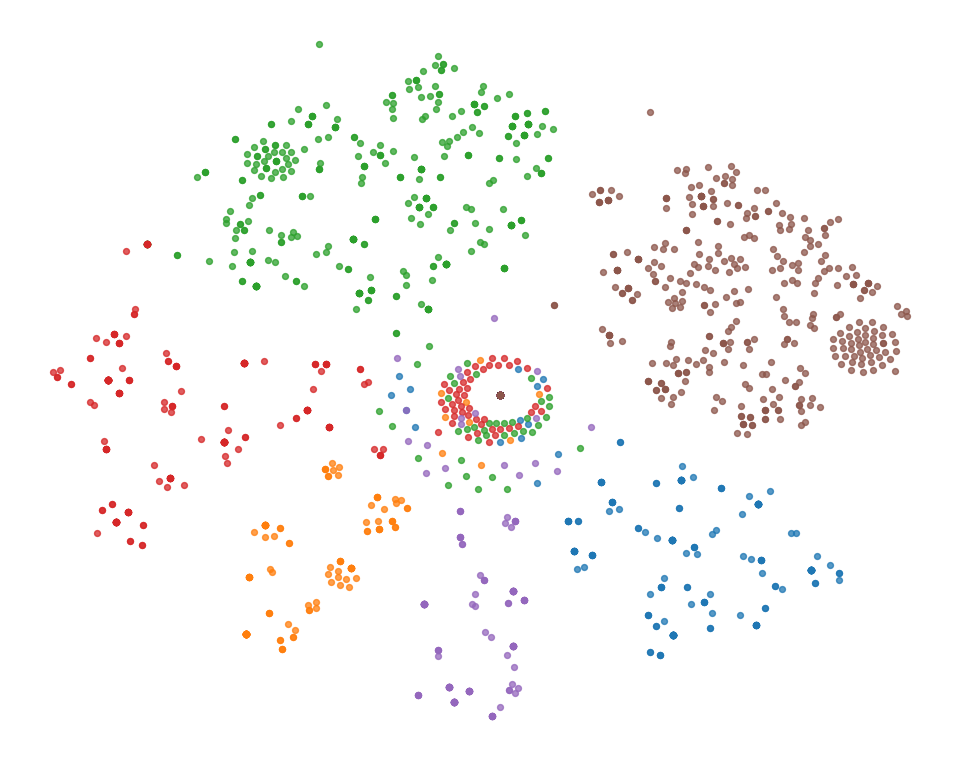

(array([[   3.3255887,    8.10279  ],
        [-101.40059  ,    4.495444 ],
        [  -6.445827 ,  -12.05541  ],
        ...,
        [   2.360484 ,   -4.9839187],
        [ -86.52988  ,    5.522484 ],
        [   2.360484 ,   -4.9839187]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [6]:
feature_matrix_labeled = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    )
plot_tsne(
    feature_matrix_labeled,
    Y,
    output_file="t-SNE-labeled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "labeled"
)

Using 2000 sampled vertices for t-SNE
SVD dimensions: 164 -> 50; explained variance: 0.793
Saved plot to t-SNE-unlabeled.pdf


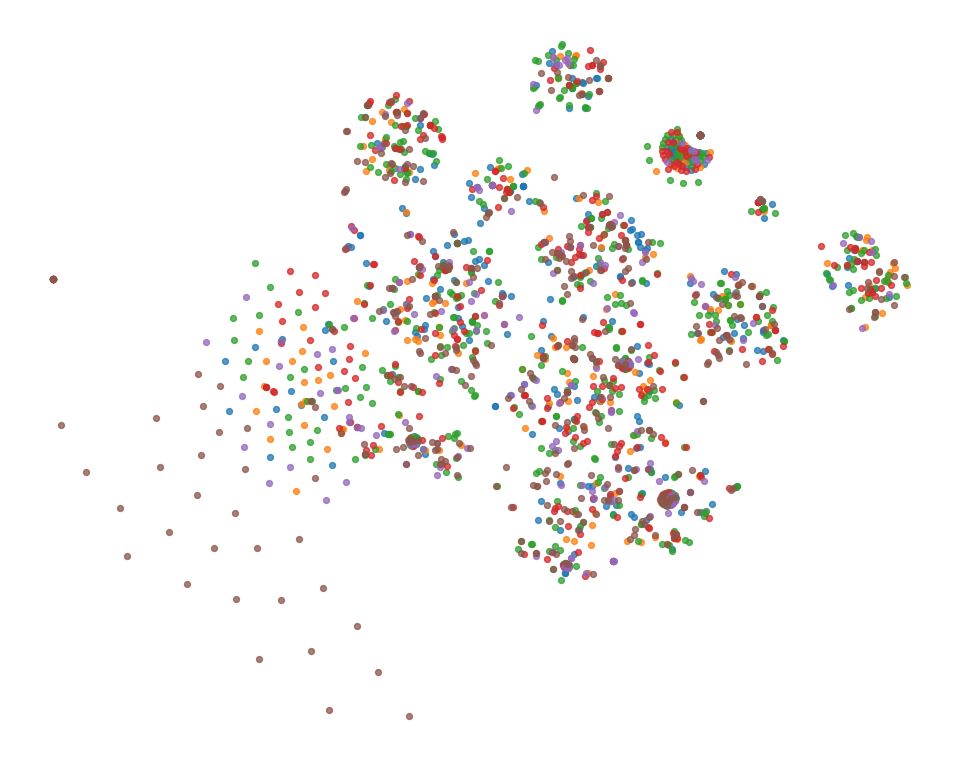

(array([[-22.130539 ,  11.444231 ],
        [-31.081703 , -20.098137 ],
        [ 13.401252 ,  24.922098 ],
        ...,
        [ 18.713953 ,  28.329014 ],
        [-25.936    ,   2.845923 ],
        [-42.08658  ,  -6.2514205]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [7]:
feature_matrix_unlabeled = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12occMap",
)
plot_tsne(
    feature_matrix_unlabeled,
    Y,
    output_file="t-SNE-unlabeled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "unlabeled"
)

Using 2000 sampled vertices for t-SNE
SVD dimensions: 27 -> 26; explained variance: 0.993
Saved plot to t-SNE-sampled.pdf


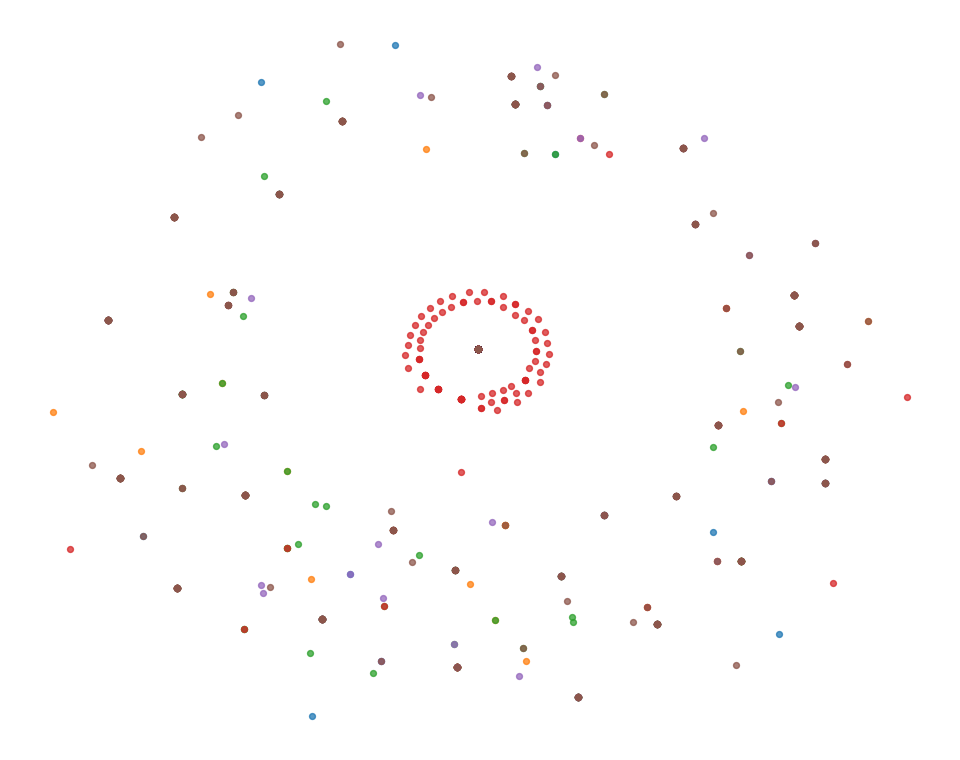

(array([[ -22.51357  ,   31.251574 ],
        [ 133.8683   ,   42.01242  ],
        [  -9.956064 ,   36.124554 ],
        ...,
        [   1.1807972,   14.428808 ],
        [-153.93231  ,   29.282982 ],
        [-124.98997  , -107.12284  ]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [8]:
feature_matrix_sampled = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12occMap",
    )
plot_tsne(
    feature_matrix_sampled,
    Y,
    output_file="t-SNE-sampled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "shuffled-label"
)

# Extract the feature matrix

## Define training function

In [ ]:
import time


run_results, model, running_times = train_and_extract_features(
    feature_matrix_labeled,
    Y,
    G,
    args,
)

features_run_1 = run_results[0]["features"]

running_times = np.array(running_times)
print(f"The mean training time: {np.mean(running_times)}")
print(f"The std training time: {np.std(running_times)}")

number of hyperedges is 22363
Run 1/10, Total Epochs: 1000
Run 1/10, Total Epochs: 1000
UniGCNII(
  (act): ReLU()
  (input_drop): Dropout(p=0.6, inplace=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (convs): ModuleList(
    (0): Linear(in_features=88, out_features=64, bias=True)
    (1-64): 64 x UniGCNIIConv(
      (W): Linear(in_features=64, out_features=64, bias=False)
    )
    (65): Linear(in_features=64, out_features=6, bias=True)
  )
)
UniGCNII(
  (act): ReLU()
  (input_drop): Dropout(p=0.6, inplace=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (convs): ModuleList(
    (0): Linear(in_features=88, out_features=64, bias=True)
    (1-64): 64 x UniGCNIIConv(
      (W): Linear(in_features=64, out_features=64, bias=False)
    )
    (65): Linear(in_features=64, out_features=6, bias=True)
  )
)
total_params:268230
total_params:268230
epoch:0 | loss:1.8015 | train acc:20.69 | val acc:24.57 | best_test_acc: 24.10 | test acc:24.10 | time:534.0ms
epoch:0 | loss:1.8015 | train acc

## Now testing with machine learning model

In [ ]:
captured = {}

def capture_classifier_input(module, inputs):
    captured["features"] = inputs[0].detach().cpu().clone()

hook = model.convs[-1].register_forward_pre_hook(
    capture_classifier_input
)



In [ ]:
feature_matrix_labeled_all_dimension = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_1000000000",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_1000000000occMap",
    )
feature_matrix_labeled_12 = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    )
unigcnii_features_by_run = {
    result["run"]: result["features"]
    for result in run_results
}

feature_sets = {
    "Labeled simplets (12 dim)": feature_matrix_labeled_12,
    "Labeled simplets (all)": feature_matrix_labeled_all_dimension,
    "Unlabeled simplets": feature_matrix_unlabeled,
    "Shuffled-label simplets": feature_matrix_sampled,
    "UniGCNII embeddings": unigcnii_features_by_run,
}

classical_results, classical_predictions = evaluate_classical_models(
    feature_sets,
    Y,
    args,
)

classical_results.to_csv(
    "classical_feature_classifier_results.csv",
    index=False,
)

classical_summary = (
    classical_results
    .groupby(["feature_set", "classifier"], as_index=False)
    .agg(
        mean_train_accuracy=("train_accuracy", "mean"),
        std_train_accuracy=(
            "train_accuracy",
            lambda values: np.std(values, ddof=0),
        ),
        mean_test_accuracy=("test_accuracy", "mean"),
        std_test_accuracy=(
            "test_accuracy",
            lambda values: np.std(values, ddof=0),
        ),
        mean_train_macro_f1=("train_macro_f1", "mean"),
        std_train_macro_f1=(
            "train_macro_f1",
            lambda values: np.std(values, ddof=0),
        ),
        mean_test_macro_f1=("test_macro_f1", "mean"),
        std_test_macro_f1=(
            "test_macro_f1",
            lambda values: np.std(values, ddof=0),
        ),
    )
    .sort_values(["classifier", "feature_set"])
)

classical_summary


## Classical classifiers across frequency thresholds

This repeats the labeled, unlabeled, and shuffled-simplet frequency sweeps for logistic regression, linear/RBF SVM, KNN, and decision trees. Each classifier uses the same ten train/test splits at every threshold.

In [ ]:
classical_frequency_sources = {
    "Labeled simplets": {
        "pattern_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "node_classification/AMiner/rerun1/"
            "AMiner_freq_100_minDim_0_maxSize_12"
        ),
        "image_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "node_classification/AMiner/rerun1/"
            "AMiner_freq_100_minDim_0_maxSize_12occMap"
        ),
        "thresholds": list(np.arange(100, 2100, 100)),
    },
    "Unlabeled simplets": {
        "pattern_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "node_classification/"
            "dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/"
            "dblp_uniGNN_old_unlabeld_simplices_PLMSC_"
            "freq_100_minDim_0_maxSize_12"
        ),
        "image_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "node_classification/"
            "dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/"
            "dblp_uniGNN_old_unlabeld_simplices_PLMSC_"
            "freq_100_minDim_0_maxSize_12occMap"
        ),
        "thresholds": list(np.arange(100, 2100, 100)),
    },
    "Shuffled-label simplets": {
        "pattern_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "AMiner_randomly_permutate_vertex_label/"
            "AMiner_randomly_permutate_vertex_label_"
            "freq_10_minDim_0_maxSize_12"
        ),
        "image_file": (
            "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/"
            "AMiner_randomly_permutate_vertex_label/"
            "AMiner_randomly_permutate_vertex_label_"
            "freq_10_minDim_0_maxSize_12occMap"
        ),
        "thresholds": list(np.arange(100, 1001, 100)),
    },
}

classical_frequency_results, classical_frequency_predictions = (
    evaluate_classical_models_by_frequency(
        classical_frequency_sources,
        Y,
        args,
    )
)

classical_frequency_results.to_csv(
    "classical_models_by_frequency.csv",
    index=False,
)

classical_frequency_summary = summarize_classical_frequency_results(
    classical_frequency_results
)
classical_frequency_summary.to_csv(
    "classical_models_by_frequency_summary.csv",
    index=False,
)

classical_frequency_summary


In [ ]:
for feature_name in classical_frequency_sources:
    file_stub = feature_name.lower().replace(" ", "_").replace("-", "_")
    plot_classical_frequency_results(
        classical_frequency_results,
        feature_name,
        output_prefix=f"classical_{file_stub}",
    )
